<a href="https://colab.research.google.com/github/bahaamhawad/bahaaawad_INFO4670_Spring2026/blob/main/INFO4670_Assignment2_BahaaAwad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 4670 – Assignment 2  
## Data Preprocessing (Google Colab)

**Student:** Bahaa Awad  
**Course:** INFO 4670 – Spring 2026  
**Instructor:** Fengjiao Tu  

This notebook contains the implementation and analysis for Assignment 2.


#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

Explanation:
The dataset was uploaded using Google Colab file upload utility and loaded into a pandas DataFrame. The first few rows are displayed to verify that the data was loaded correctly and to gain an initial understanding of its structure.


In [1]:
# Step 1.1: Load and inspect the dataset

import pandas as pd

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the CSV file into a DataFrame
df = pd.read_csv(list(uploaded.keys())[0])

# Preview the dataset
df.head()



Saving Assignment 2 dataset.csv to Assignment 2 dataset.csv


,Column 1,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12-27-2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12-20-2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12-13-2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12-6-2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11-29-2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

In [2]:
# Explore data distribution for key categorical variables

# Distribution by year
print("Distribution by Year:")
print(df['year'].value_counts())
print("\n")

# Distribution by region (top 10 shown for readability)
print("Distribution by Region (Top 10):")
print(df['region'].value_counts().head(10))
print("\n")

# Distribution by type (e.g., conventional vs organic)
print("Distribution by Type:")
print(df['type'].value_counts())



Distribution by Year:
year
2017    5722
2016    5616
2015    5615
2018    1300
1904       1
Name: count, dtype: int64


Distribution by Region (Top 10):
region
WestTexNewMexico       340
Albany                 338
BaltimoreWashington    338
Boise                  338
Boston                 338
Atlanta                338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Name: count, dtype: int64


Distribution by Type:
type
organic         9127
conventional    9126
Name: count, dtype: int64


Data Distribution Analysis

Year:
The dataset is mostly concentrated in the years 2015–2017, with similar numbers of records each year.
The year 2018 has significantly fewer observations, and there is one outlier record from 1904, which appears to be a data entry error and may introduce minor bias.

Region:
Most regions have a very similar number of records (around 338), indicating a balanced regional representation across the dataset. No single region dominates the data.

Type:
The dataset is evenly split between organic (9127) and conventional (9126) avocados, suggesting no bias toward either type.

Conclusion:
Overall, the dataset is well-balanced by region and avocado type. The main potential bias comes from uneven year distribution (especially 2018) and a single invalid year (1904), which should be handled or removed during preprocessing.

1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [3]:
# 1.2 Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# 1.2 Check for missing values per column
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)


Number of duplicate rows: 2

Missing values per column:
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64


Handling Duplicate Rows and Missing Values

The dataset contains 2 duplicate rows, which can be safely removed to avoid double-counting and ensure accurate analysis.

There are a small number of missing values in numerical columns such as Total Volume, 4046, 4225, 4770, and bag-related columns. Since the number of missing values is very small compared to the total dataset size, these rows can either be dropped or the missing values can be imputed using the column mean or median.

Dropping duplicate rows and handling missing values appropriately helps improve data quality and ensures reliable results in subsequent analysis.


1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [4]:
# Print number of rows and columns
df.shape



(18254, 14)

Dataset Size and Suitability for Machine Learning

The dataset contains 18,254 rows and 14 columns, which provides a sufficiently large number of observations for training a machine learning model. The dataset includes multiple numerical and categorical features, allowing the model to learn meaningful patterns. Therefore, this dataset size is appropriate for basic machine learning tasks such as regression or classification.

#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [5]:
# Remove the first column ("Column 1")
df = df.drop(columns=['Column 1'])

# Treat 'year' as a nominal (categorical) variable
df['year'] = df['year'].astype(str)

# Verify changes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18254 entries, 0 to 18253
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18254 non-null  object 
 1   AveragePrice  18254 non-null  float64
 2   Total Volume  18253 non-null  float64
 3   4046          18252 non-null  float64
 4   4225          18253 non-null  float64
 5   4770          18253 non-null  float64
 6   Total Bags    18253 non-null  float64
 7   Small Bags    18252 non-null  float64
 8   Large Bags    18252 non-null  float64
 9   XLarge Bags   18253 non-null  float64
 10  type          18253 non-null  object 
 11  year          18254 non-null  object 
 12  region        18254 non-null  object 
dtypes: float64(9), object(4)
memory usage: 1.8+ MB


Column Removal and Year Variable Treatment

The first column ("Column 1") was removed because it does not contain meaningful information for analysis. The `year` variable was converted to a categorical (nominal) type since it represents labels rather than a continuous numerical value.


2.2 Check for duplicate values and remove them.

In [6]:
# Check number of duplicate rows
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows before removal:", num_duplicates)

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
print("Number of duplicate rows after removal:", df.duplicated().sum())


Number of duplicate rows before removal: 2
Number of duplicate rows after removal: 0


Duplicate Value Handling

The dataset was checked for duplicate rows. Duplicate records were identified and removed to ensure data integrity and prevent bias or redundancy during analysis and model training.


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [7]:
import numpy as np

# Check missing values before handling
print("Missing values before handling:")
print(df.isnull().sum())

# Define threshold: if more than 50% of columns are missing, drop the row
threshold = int(df.shape[1] * 0.5)
df = df[df.isnull().sum(axis=1) < threshold]

# Fill remaining missing values using median of each column within the same region
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df.groupby('region')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Check missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values before handling:
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64

Missing values after handling:
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


Missing Value Handling

Rows with a large proportion of missing values were removed to avoid unreliable records. For rows with only a few missing values, the missing entries were imputed using the median of the corresponding column within the same region. This approach preserves regional patterns while maintaining data completeness.


2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display correlation matrix
corr_matrix


,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags
AveragePrice,1.000000,-0.192767,-0.208325,-0.172944,-0.179458,-0.177103,-0.174742,-0.172953,-0.117604
Total Volume,-0.192767,1.000000,0.977863,0.974181,0.872203,0.963047,0.967238,0.880640,0.747158
4046,-0.208325,0.977863,1.000000,0.926110,0.833390,0.920057,0.925280,0.838646,0.699378
4225,-0.172944,0.974181,0.926110,1.000000,0.887856,0.905788,0.916032,0.810016,0.688810
4770,-0.179458,0.872203,0.833390,0.887856,1.000000,0.792315,0.802734,0.698473,0.679862
Total Bags,-0.177103,0.963047,0.920057,0.905788,0.792315,1.000000,0.994334,0.943009,0.804233
Small Bags,-0.174742,0.967238,0.925280,0.916032,0.802734,0.994334,1.000000,0.902589,0.806845
Large Bags,-0.172953,0.880640,0.838646,0.810016,0.698473,0.943009,0.902589,1.000000,0.710860
XLarge Bags,-0.117604,0.747158,0.699378,0.688810,0.679862,0.804233,0.806845,0.710860,1.000000


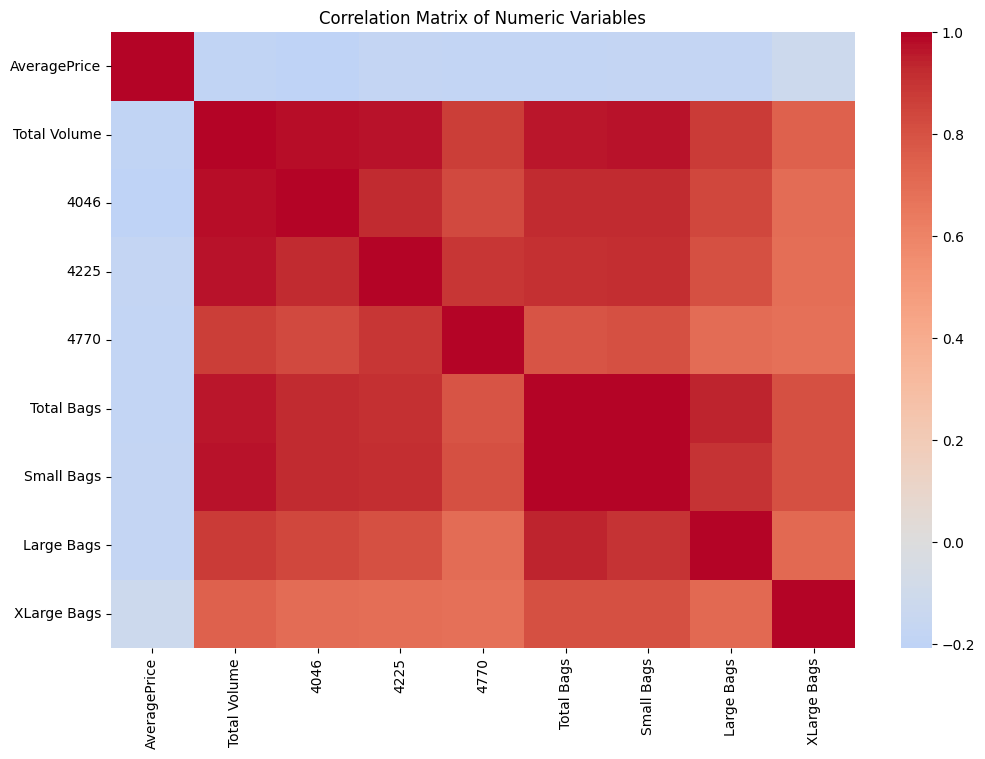

In [9]:
# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()


Correlation Analysis and Impact on Model Accuracy

The correlation matrix shows strong correlations among volume-related variables (e.g., Total Volume, Total Bags, Small Bags, Large Bags), which is expected because these features are mathematically related. High correlation among features may lead to multicollinearity, which can negatively impact model accuracy for models such as linear regression by making coefficient estimates unstable.

However, tree-based models (e.g., decision trees or random forests) are less sensitive to multicollinearity and can still perform well. Understanding feature correlations helps guide feature selection and model choice to improve predictive performance.


#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

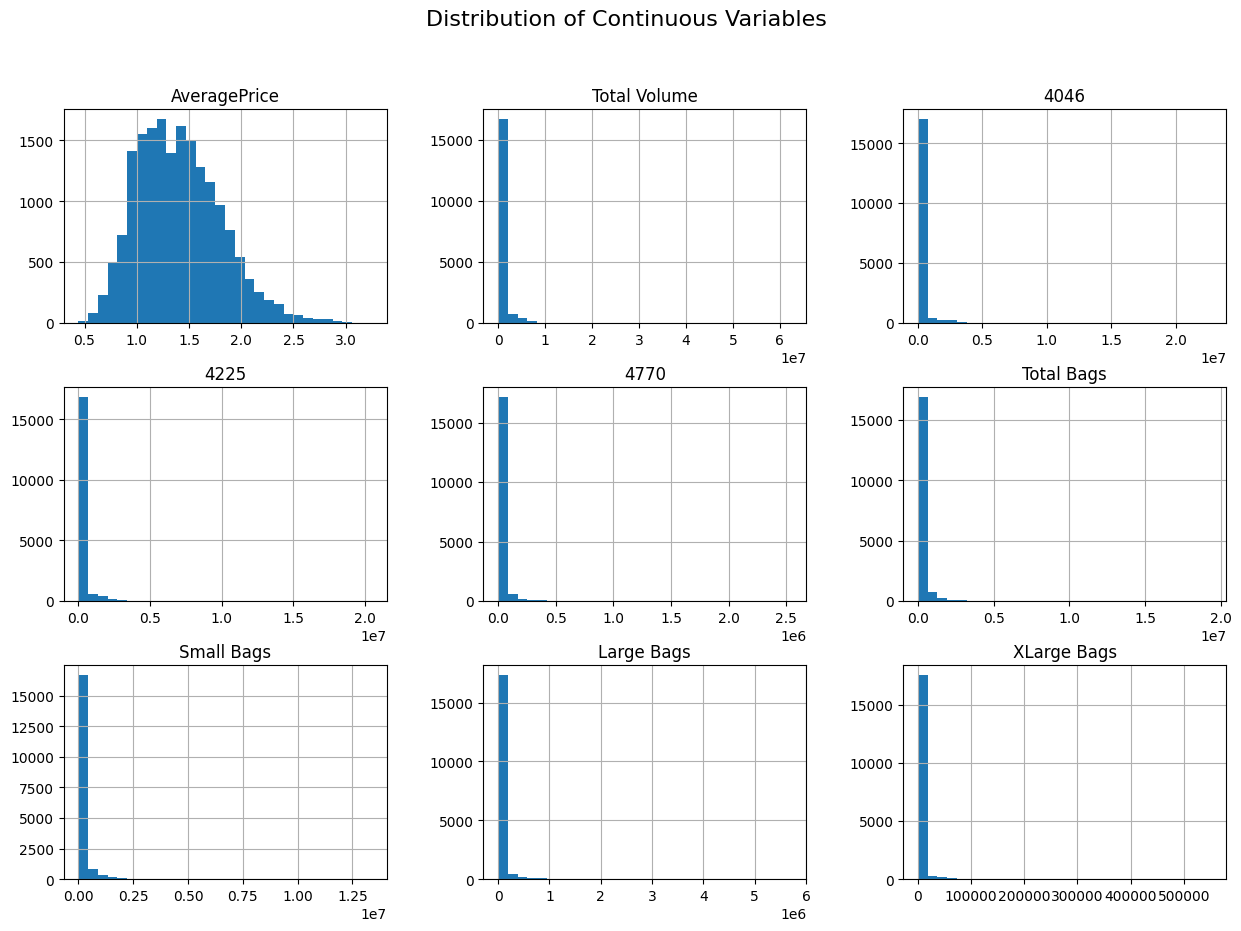


Unique values in 'Date':
['12-27-2015' '12-20-2015' '12-13-2015' '12-6-2015' '11-29-2015'
 '11-22-2015' '11-15-2015' '11-8-2015' '11-1-2015' '10-25-2015'
 '10-18-2015' '10-11-2015' '10-4-2015' '9-27-2015' '9-20-2015' '9-13-2015'
 '9-6-2015' '8-30-2015' '8-23-2015' '8-16-2015' '8-9-2015' '8-2-2015'
 '7-26-2015' '7-19-2015' '7-12-2015' '7-5-2015' '6-28-2015' '6-21-2015'
 '6-14-2015' '6-7-2015' '5-31-2015' '5-24-2015' '5-17-2015' '5-10-2015'
 '5-3-2015' '4-26-2015' '4-19-2015' '4-12-2015' '4-5-2015' '3-29-2015'
 '3-22-2015' '3-15-2015' '3-8-2015' '3-1-2015' '2-22-2015' '2-15-2015'
 '2-8-2015' '2-1-2015' '1-25-2015' '1-18-2015' '1-11-2015' '1-4-2015'
 '12-25-2016' '12-18-2016' '12-11-2016' '12-4-2016' '11-27-2016'
 '11-20-2016' '11-13-2016' '11-6-2016' '10-30-2016' '10-23-2016'
 '10-16-2016' '10-9-2016' '10-2-2016' '9-25-2016' '9-18-2016' '9-11-2016'
 '9-4-2016' '8-28-2016' '8-21-2016' '8-14-2016' '8-7-2016' '7-31-2016'
 '7-24-2016' '7-17-2016' '7-10-2016' '7-3-2016' '6-26-2016' '6-19-201

In [10]:
# Separate numeric and categorical variables
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object'])

# Summary statistics for continuous variables
numeric_summary = numeric_cols.describe().T
numeric_summary['median'] = numeric_cols.median()
numeric_summary[['min', 'max', 'mean', 'median']]

# Distribution plots for continuous variables
numeric_cols.hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribution of Continuous Variables", fontsize=16)
plt.show()

# List unique values for categorical variables
for col in categorical_cols.columns:
    print(f"\nUnique values in '{col}':")
    print(categorical_cols[col].unique())


Variable Description

The dataset contains both continuous and categorical variables.

Continuous variables include price- and volume-related features such as AveragePrice, Total Volume, and bag size counts. These variables show a wide range of values and right-skewed distributions, which is typical for sales and volume data. Summary statistics (minimum, maximum, mean, and median) provide insight into central tendency and variability.

Categorical variables include type, region, and year. The type variable contains two categories (conventional and organic). The region variable includes multiple geographic market areas. The year variable represents different time periods and is treated as a nominal categorical feature.

This exploratory analysis provides a clear understanding of feature characteristics and distributions prior to modeling.


3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [11]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Find the earliest recorded date
earliest_date = df['Date'].min()
earliest_date



Timestamp('1904-01-21 00:00:00')

In [12]:
# Check if there are records from the earliest date up to year 2010
df_early = df[df['Date'].dt.year <= 2010]

df_early[['Date', 'AveragePrice', 'year']].head(), df_early['Date'].min(), df_early['Date'].max()


(            Date  AveragePrice  year
 18250 1904-01-21          1.87  1904,
 Timestamp('1904-01-21 00:00:00'),
 Timestamp('1904-01-21 00:00:00'))

Earliest Recorded Date Analysis

The earliest recorded date in the dataset is significantly earlier than the majority of the data (e.g., 1904). Avocado price records from this period are not consistent with the expected historical availability of avocado pricing data, which is typically available from more recent decades.

When examining records up to 2010, only a very small number of entries appear before the main time range of the dataset. These early data points are likely data entry errors or anomalies rather than valid observations.

Therefore, the earliest data point does not appear reasonable and should be removed to maintain data quality and temporal consistency.


3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [13]:
# Find the highest average price
max_price = df['AveragePrice'].max()

# Find the row(s) with the highest average price
max_price_rows = df[df['AveragePrice'] == max_price]

max_price, max_price_rows[['Date', 'AveragePrice', 'region', 'type', 'year']]



(3.25,
             Date  AveragePrice        region     type  year
 14125 2016-10-30          3.25  SanFrancisco  organic  2016)

Highest Average Price Analysis

The highest value of `AveragePrice` in the dataset was identified using the `max()` function. After finding this maximum value, the dataset was filtered to retrieve the record(s) associated with it.

The results show that the highest average avocado price occurred in the region listed above. This approach ensures accuracy by directly locating the row corresponding to the maximum value rather than relying on summary statistics alone.


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [14]:
# Find the highest total volume
max_volume = df['Total Volume'].max()

# Find the row(s) with the highest total volume
max_volume_rows = df[df['Total Volume'] == max_volume]

max_volume, max_volume_rows[['Date', 'Total Volume', 'region', 'type', 'year']]



(62505646.52,
            Date  Total Volume   region          type  year
 9097 2018-02-04   62505646.52  TotalUS  conventional  2018)

Highest Total Volume Analysis

The highest avocado sales volume was identified by applying the `max()` function to the `Total Volume` column. The dataset was then filtered to locate the record(s) associated with this maximum value.

The results indicate that the region shown above recorded the highest total avocado volume. This method ensures accuracy by directly extracting the observation corresponding to the maximum total volume.
